# Final Project

Combined notebook: Phase 2 & 3, Phase 4, and Phase 5.

In [2]:
import sys
print(sys.executable)

/Users/shubhvaishnav/Desktop/590/590/.venv_plot/bin/python


In [3]:
# Local Spark session (run this cell first when running outside Databricks)
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("CampaignAnalysis") \
    .master("local[*]") \
    .getOrCreate()
print("Spark session ready:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/05 01:06:05 WARN Utils: Your hostname, Shubhs-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 100.70.79.150 instead (on interface en0)
26/03/05 01:06:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 01:06:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session ready: 4.1.1


## Phase 2 & 3

Predicting High-Performance Marketing Campaigns and Optimizing Budget Allocation Using Distributed ML

structured dataset

# Phase 2

In [4]:
# Imports
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from functools import reduce
import re

## 1) Paths (raw files)

In [5]:
paths = {
    "nykaa":   "data/nykaa_campaign_data.csv",
    "purplle": "data/purplle_campaign_data.csv",
    "tira":    "data/tira_campaign_data.csv"
}

# silver path and gold path
silver_path = "data/marketing_silver_parquet"
gold_path   = "data/marketing_gold_parquet"

## 2) Helper functions

In [6]:
def align_cols(df, all_cols):
    for c in all_cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    return df.select(all_cols)

# Normalize column names: lowercase, replace non-alphanumerics with underscore
def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c


def read_campaign(path: str, brand: str):
    # Read raw CSV and standardize schema
    df = (spark.read
          .option("header", True)
          .option("inferSchema", True)
          .csv(path))

    # Normalize column names
    for old in df.columns:
        df = df.withColumnRenamed(old, normalize_colname(old))

    # Add brand_source column
    df = df.withColumn("brand_source", F.lit(brand))
    return df


# safe_div => to avoid division-by-zero (returns null if denominator <= 0 or null)
def safe_div(num_col, den_col):
    return F.when((den_col.isNotNull()) & (den_col > 0) & (num_col.isNotNull()), num_col / den_col)

## 3) Ingest + Union all sources

In [7]:
dfs = [read_campaign(p, b) for b, p in paths.items()]
all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))

dfs_aligned = [align_cols(d, all_cols) for d in dfs]
df_all = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs_aligned)

# Drop duplicates (exactly same rows)
df_all = df_all.dropDuplicates()

df_all.printSchema()

root
 |-- acquisition_cost: double (nullable = true)
 |-- brand_source: string (nullable = false)
 |-- campaign_id: string (nullable = true)
 |-- campaign_type: string (nullable = true)
 |-- channel_used: string (nullable = true)
 |-- clicks: integer (nullable = true)
 |-- conversions: integer (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- date: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- engagement_score: double (nullable = true)
 |-- impressions: integer (nullable = true)
 |-- language: string (nullable = true)
 |-- leads: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- roi: double (nullable = true)
 |-- target_audience: string (nullable = true)



## 4) Basic cleaning
strings + sanity check

In [8]:
# Identify string columns
string_cols = [c for c, t in df_all.dtypes if t == "string"]

# Fill nulls in string cols as "Unknown"
df_all = df_all.fillna({c: "Unknown" for c in string_cols})

# Trim whitespace in string cols
for c in string_cols:
    df_all = df_all.withColumn(c, F.trim(F.col(c)))

# Quick sanity check for negative values
nonneg_cols = [c for c, t in df_all.dtypes if t in ("int", "bigint", "double", "float") and c not in ("roi",)]
for c in nonneg_cols:
    df_all = df_all.withColumn(
        c,
        F.when(F.col(c) < 0, None).otherwise(F.col(c))
    )

## 5) Feature engineering
### KPI + Funnel metrics

In [9]:
df_feat = (df_all
    .withColumn("ctr", safe_div(F.col("clicks"), F.col("impressions")))              # clicks / impressions
    .withColumn("lead_rate", safe_div(F.col("leads"), F.col("clicks")))              # leads / clicks
    .withColumn("lead_to_conv", safe_div(F.col("conversions"), F.col("leads")))      # conversions / leads
    .withColumn("click_to_conv", safe_div(F.col("conversions"), F.col("clicks")))    # conversions / clicks (overall)
    .withColumn("cpc", safe_div(F.col("acquisition_cost"), F.col("clicks")))         # cost / clicks
    .withColumn("cpa", safe_div(F.col("acquisition_cost"), F.col("conversions")))    # cost / conversions
    .withColumn("roas", safe_div(F.col("revenue"), F.col("acquisition_cost")))       # revenue / cost
    .withColumn("rpm", safe_div(F.col("revenue").cast("double") * 1000, F.col("impressions"))) # revenue per 1000 impressions
)


# (for safety) Keep ratio metrics within [0, 1] where applicable (funnel rates)
df_feat = (df_feat
    .withColumn("ctr", F.when((F.col("ctr") < 0) | (F.col("ctr") > 1), None).otherwise(F.col("ctr")))
    .withColumn("lead_rate", F.when((F.col("lead_rate") < 0) | (F.col("lead_rate") > 1), None).otherwise(F.col("lead_rate")))
    .withColumn("lead_to_conv", F.when((F.col("lead_to_conv") < 0) | (F.col("lead_to_conv") > 1), None).otherwise(F.col("lead_to_conv")))
    .withColumn("click_to_conv", F.when((F.col("click_to_conv") < 0) | (F.col("click_to_conv") > 1), None).otherwise(F.col("click_to_conv")))
)

# display
display(
    df_feat.select(
        "brand_source", "impressions", "clicks", "leads", "conversions",
        "ctr", "lead_rate", "lead_to_conv", "click_to_conv", "cpc", "cpa", "roas"
    ).limit(20)
)

DataFrame[brand_source: string, impressions: int, clicks: int, leads: int, conversions: int, ctr: double, lead_rate: double, lead_to_conv: double, click_to_conv: double, cpc: double, cpa: double, roas: double]

## 6) Save Silver layer
The Silver layer contains cleaned and feature-engineered campaign data.
At this stage, the raw campaign datasets from multiple brands are merged, basic cleaning is applied (null handling, trimming, sanity checks), and marketing KPIs and funnel metrics are created (CTR, CPC, CPA, ROAS, etc.).
This represents row-level campaign performance and serves as the foundation for further analysis and modeling.

In [10]:
# Save engineered row-level dataset as Silver
(df_feat
 .write
 .mode("overwrite")
 .parquet(silver_path))

# Reload Silver and register a temp view
df_silver = spark.read.parquet(silver_path)
df_silver.createOrReplaceTempView("marketing_silver")

# schema check
df_silver.printSchema()
display(df_silver.limit(5))

26/03/05 01:06:11 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/05 01:06:11 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/05 01:06:11 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers


root
 |-- acquisition_cost: double (nullable = true)
 |-- brand_source: string (nullable = true)
 |-- campaign_id: string (nullable = true)
 |-- campaign_type: string (nullable = true)
 |-- channel_used: string (nullable = true)
 |-- clicks: integer (nullable = true)
 |-- conversions: integer (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- date: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- engagement_score: double (nullable = true)
 |-- impressions: integer (nullable = true)
 |-- language: string (nullable = true)
 |-- leads: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- roi: double (nullable = true)
 |-- target_audience: string (nullable = true)
 |-- ctr: double (nullable = true)
 |-- lead_rate: double (nullable = true)
 |-- lead_to_conv: double (nullable = true)
 |-- click_to_conv: double (nullable = true)
 |-- cpc: double (nullable = true)
 |-- cpa: double (nullable = true)
 |-- roas: double (nullable = true)


26/03/05 01:06:12 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/05 01:06:12 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


DataFrame[acquisition_cost: double, brand_source: string, campaign_id: string, campaign_type: string, channel_used: string, clicks: int, conversions: int, customer_segment: string, date: string, duration: int, engagement_score: double, impressions: int, language: string, leads: int, revenue: int, roi: double, target_audience: string, ctr: double, lead_rate: double, lead_to_conv: double, click_to_conv: double, cpc: double, cpa: double, roas: double, rpm: double]

# Phase 3

## 1) Summary statistics

In [11]:
display(df_silver.summary())

DataFrame[summary: string, acquisition_cost: string, brand_source: string, campaign_id: string, campaign_type: string, channel_used: string, clicks: string, conversions: string, customer_segment: string, date: string, duration: string, engagement_score: string, impressions: string, language: string, leads: string, revenue: string, roi: string, target_audience: string, ctr: string, lead_rate: string, lead_to_conv: string, click_to_conv: string, cpc: string, cpa: string, roas: string, rpm: string]

In [12]:
spark.sql("""
SELECT
    COUNT(*) AS total_rows,
    AVG(clicks) AS avg_clicks,
    AVG(impressions) AS avg_impressions,
    AVG(conversions) AS avg_conversions,
    AVG(ctr) AS avg_ctr,
    AVG(roas) AS avg_roas
FROM marketing_silver
""").show()

+----------+-----------------+----------------+-----------------+-------------------+-----------------+
|total_rows|       avg_clicks| avg_impressions|  avg_conversions|            avg_ctr|         avg_roas|
+----------+-----------------+----------------+-----------------+-------------------+-----------------+
|    166665|4682.367545675456|55060.8540905409|1029.088884888849|0.08502327064407401|6439.071819279485|
+----------+-----------------+----------------+-----------------+-------------------+-----------------+



## 2) Feature Distributions

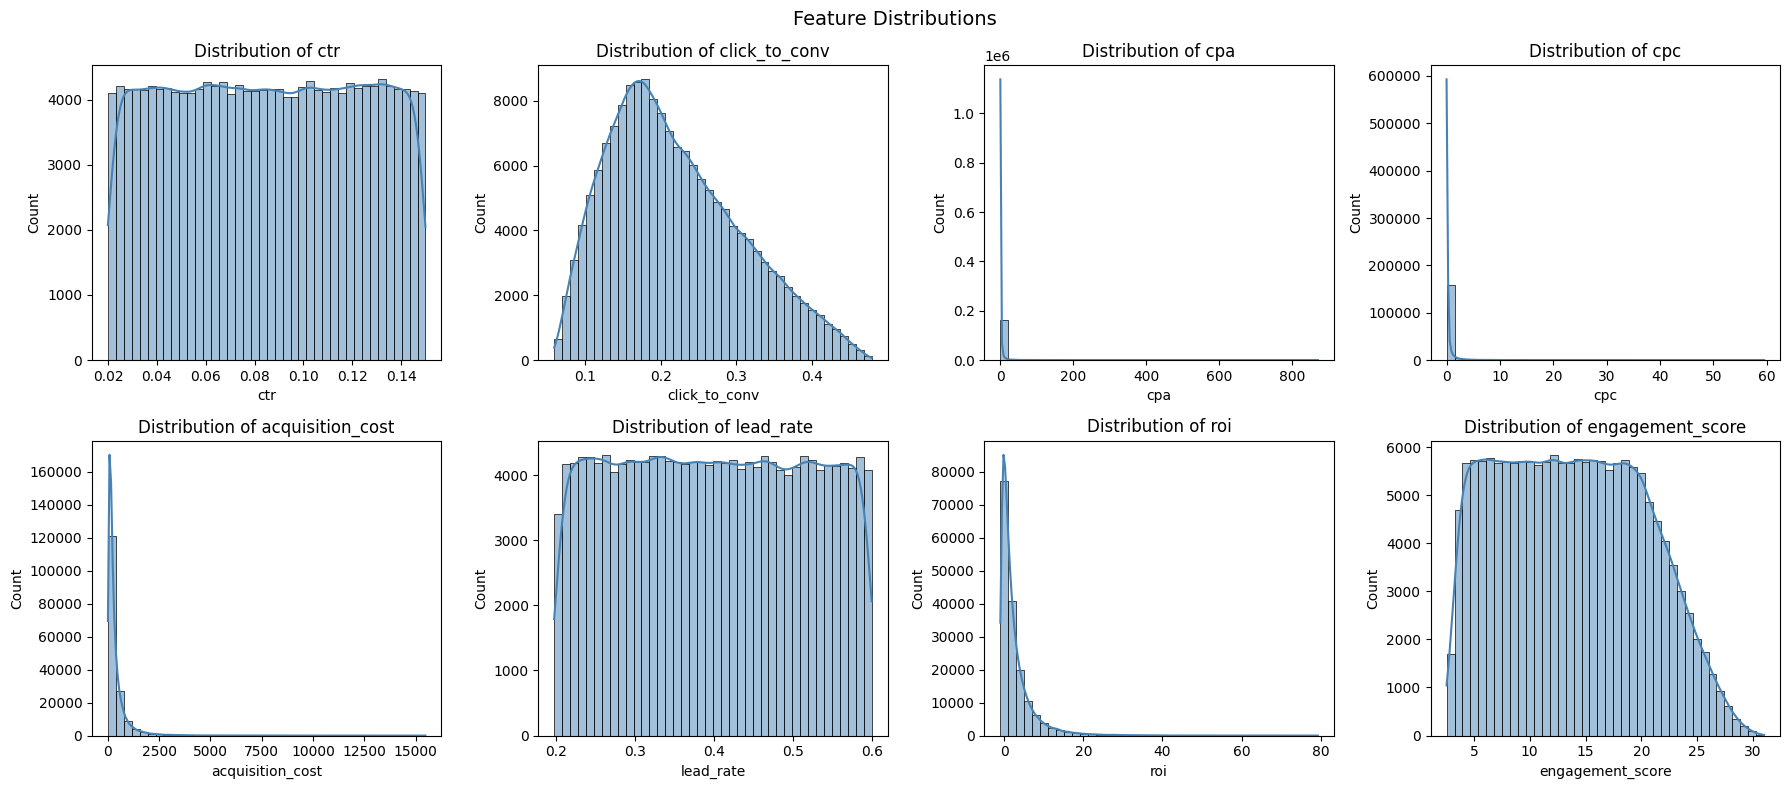

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect for visualization
pdf = (df_silver
    .select("ctr", "click_to_conv", "cpa", "cpc", "acquisition_cost", 
            "lead_rate", "roi", "engagement_score")
    .dropna()
    .toPandas()
)

# Distribution of each feature
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features = ["ctr", "click_to_conv", "cpa", "cpc", 
            "acquisition_cost", "lead_rate", "roi", "engagement_score"]

for ax, col in zip(axes.flat, features):
    sns.histplot(pdf[col], kde=True, ax=ax, bins=40, color="steelblue")
    ax.set_title(f"Distribution of {col}")

plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 3) Correlation Heatmap
Correlation matrix to detect multicollinearity

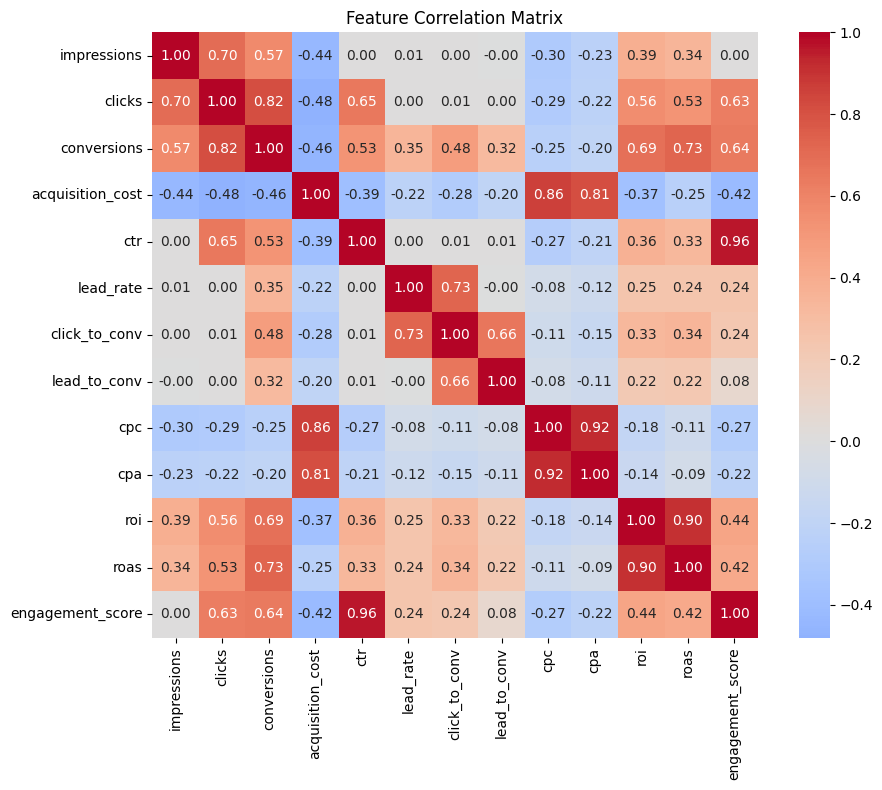

In [14]:
corr_cols = ["impressions", "clicks", "conversions", "acquisition_cost",
             "ctr", "lead_rate", "click_to_conv", "lead_to_conv",
             "cpc", "cpa", "roi", "roas", "engagement_score"]

corr_matrix = (df_silver
    .select(corr_cols)
    .dropna()
    .toPandas()
    .corr()
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 4) Monthly ROAS trend

In [15]:
# Check date range per brand
display(spark.sql("""
SELECT 
    brand_source,
    MIN(date) AS start_date,
    MAX(date) AS end_date,
    COUNT(*) AS n_campaigns
FROM marketing_silver
GROUP BY brand_source
ORDER BY brand_source
"""))

DataFrame[brand_source: string, start_date: string, end_date: string, n_campaigns: bigint]

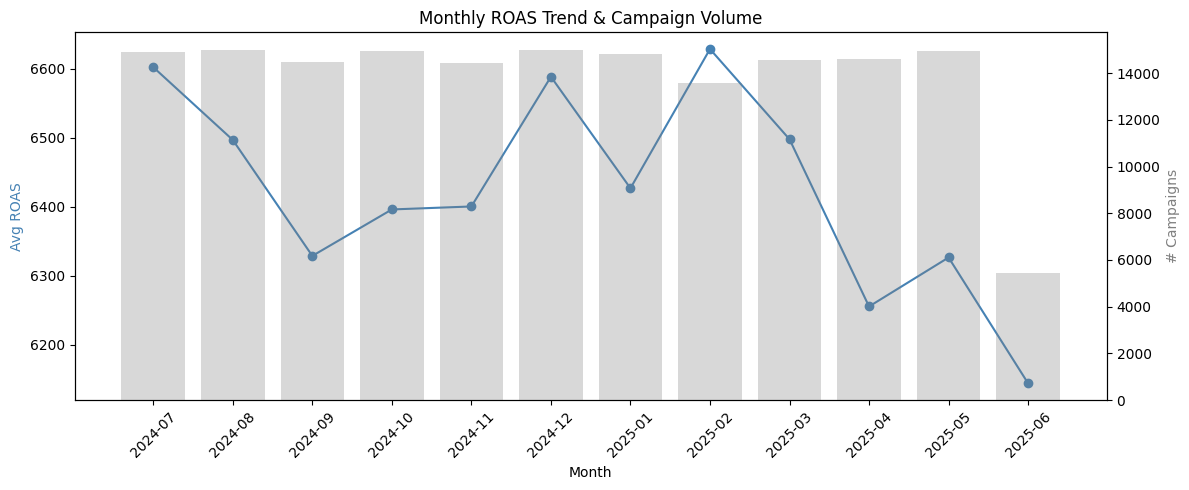

In [16]:
monthly_trend = spark.sql("""
SELECT
    DATE_FORMAT(to_date(date, 'dd-MM-yyyy'), 'yyyy-MM') AS month,
    ROUND(AVG(roas), 2)           AS avg_roas,
    ROUND(AVG(ctr), 4)           AS avg_ctr,
    COUNT(*)                     AS n_campaigns
FROM marketing_silver
GROUP BY DATE_FORMAT(to_date(date, 'dd-MM-yyyy'), 'yyyy-MM')
ORDER BY month
""").toPandas()
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_trend["month"], monthly_trend["avg_roas"], marker="o", color="steelblue", label="Avg ROAS")
ax1.set_xlabel("Month")
ax1.set_ylabel("Avg ROAS", color="steelblue")
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.bar(monthly_trend["month"], monthly_trend["n_campaigns"], alpha=0.3, color="gray", label="# Campaigns")
ax2.set_ylabel("# Campaigns", color="gray")
plt.title("Monthly ROAS Trend & Campaign Volume")
fig.tight_layout()
plt.show()

## 5) Performance by campaign type

In [17]:
display(spark.sql("""
SELECT
    campaign_type,
    COUNT(*) AS n_campaigns,
    ROUND(AVG(roas), 2)           AS avg_roas,
    ROUND(AVG(ctr), 4)           AS avg_ctr,
    ROUND(AVG(click_to_conv), 4) AS avg_conversion,
    ROUND(AVG(cpa), 2)           AS avg_cpa
FROM marketing_silver
GROUP BY campaign_type
ORDER BY avg_roas DESC
"""))

DataFrame[campaign_type: string, n_campaigns: bigint, avg_roas: double, avg_ctr: double, avg_conversion: double, avg_cpa: double]

## 6) Channel explode

In [18]:
df_channel = (df_silver
    .withColumn("channel", F.explode(F.split(F.col("channel_used"), ",")))
    .withColumn("channel", F.trim(F.col("channel")))
)

display(
    df_channel.groupBy("channel")
    .agg(
        F.count("*").alias("n"),
        F.avg("roas").alias("avg_roas"),
        F.avg("ctr").alias("avg_ctr")
    )
    .orderBy(F.desc("avg_roas"))
)

DataFrame[channel: string, n: bigint, avg_roas: double, avg_ctr: double]

## → Save Gold layer
The Gold layer is built on top of the Silver layer by adding the binary target 'label' based on the top 25% ROAS threshold identified during EDA. While the Silver layer serves as the foundation for exploratory analysis, the Gold layer is the final modeling-ready dataset. It contains all cleaned features, engineered KPIs, and the label column that the classifier will be trained to predict in Phase 4.

In [19]:
# Define target label: top 25% ROAS
# high performance (1), else (0)
q75 = df_silver.approxQuantile("roas", [0.75], 0.01)[0]

df_gold = df_silver.withColumn(
    "label",
    F.when(F.col("roas") >= q75, 1).otherwise(0)
)

(df_gold
 .write
 .mode("overwrite")
 .parquet(gold_path))

df_gold = spark.read.parquet(gold_path)
df_gold.createOrReplaceTempView("marketing_gold")

26/03/05 01:06:16 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/03/05 01:06:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/05 01:06:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/05 01:06:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/03/05 01:06:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/05 01:06:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


The target label is defined as 1 if a campaign's ROAS is in the top 25% of all campaigns, and 0 otherwise. 

This threshold was chosen because labeling only the top quartile as high-performing sets a meaningful and selective standard. It aligns with the project goal of identifying campaigns that generate strong revenue returns relative to advertising spend.

ROAS was selected as the primary performance metric because it directly measures the revenue generated per unit of advertising spend, making it a widely used indicator of marketing campaign effectiveness.

## Phase 4

In [20]:
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

from pyspark.ml.classification import LogisticRegression, GBTClassifier

from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [21]:
from pyspark.sql import functions as F
from pyspark.sql import types as T
from functools import reduce
import re

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Paths (raw files)
paths = {
    "nykaa":   "data/nykaa_campaign_data.csv",
    "purplle": "data/purplle_campaign_data.csv",
    "tira":    "data/tira_campaign_data.csv"
}

# Helper functions
def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def read_campaign(path: str, brand: str):
    df = (spark.read
          .option("header", True)
          .option("inferSchema", True)
          .csv(path))

    # normalize column names
    for old in df.columns:
        df = df.withColumnRenamed(old, normalize_colname(old))

    # add source column
    df = df.withColumn("brand_source", F.lit(brand))
    
    return df

# add missing columns as nulls
def align_cols(df, all_cols):
    for c in all_cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    return df.select(*all_cols)

# Load + Union
dfs = [read_campaign(p, b) for b, p in paths.items()]
all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))

dfs_aligned = [align_cols(d, all_cols) for d in dfs]
df_all = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs_aligned)

# drop exact duplicate rows
df = df_all.dropDuplicates()
df.printSchema()

root
 |-- acquisition_cost: double (nullable = true)
 |-- brand_source: string (nullable = false)
 |-- campaign_id: string (nullable = true)
 |-- campaign_type: string (nullable = true)
 |-- channel_used: string (nullable = true)
 |-- clicks: integer (nullable = true)
 |-- conversions: integer (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- date: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- engagement_score: double (nullable = true)
 |-- impressions: integer (nullable = true)
 |-- language: string (nullable = true)
 |-- leads: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- roi: double (nullable = true)
 |-- target_audience: string (nullable = true)



In [22]:
# Make date a proper date type (data is DD-MM-YYYY e.g. "24-01-2025")
df = df.withColumn("date", F.to_date(F.col("date"), "dd-MM-yyyy"))

# Create time features
df = (df
      .withColumn("year", F.year("date"))
      .withColumn("month", F.month("date"))
      .withColumn("dayofweek", F.dayofweek("date"))
)

In [23]:
# Only run if you have a single channel column like "channel_used"
channels = ["facebook", "whatsapp", "youtube", "google", "email", "instagram"]

df = df.withColumn("channel_used_lc", F.lower(F.col("channel_used")))

for ch in channels:
    df = df.withColumn(f"ch_{ch}", (F.col("channel_used_lc") == F.lit(ch)).cast("int"))

df = df.drop("channel_used_lc")

In [24]:
# Cast ROI to double
df = df.withColumn("roi_d", F.col("roi").cast("double"))

# Compute median ROI using approxQuantile
median_roi = df.approxQuantile("roi_d", [0.5], 0.001)[0]
print("Median ROI:", median_roi)

# Binary label
df = df.withColumn("label", (F.col("roi_d") > F.lit(median_roi)).cast("int"))

Median ROI: 1.23


In [25]:
categorical_cols = ["brand_source", "campaign_type", "customer_segment", "language"]

numeric_cols = ["duration", "year", "month", "dayofweek"]

channel_cols = ["ch_facebook", "ch_whatsapp", "ch_youtube", "ch_google", "ch_email", "ch_instagram"]

In [26]:
indexers = []
for c in categorical_cols:
    idx = StringIndexer()
    idx = idx.setInputCol(c).setOutputCol(c + "_idx").setHandleInvalid("keep")
    indexers.append(idx)

indexed_cols = [c + "_idx" for c in categorical_cols]

In [27]:
encoder = OneHotEncoder()
encoder = encoder.setInputCols(indexed_cols).setOutputCols([c + "_ohe" for c in categorical_cols])
ohe_cols = [c + "_ohe" for c in categorical_cols]

In [28]:
assembler_inputs = numeric_cols + channel_cols + ohe_cols

assembler = VectorAssembler()
assembler = assembler.setInputCols(assembler_inputs).setOutputCol("features").setHandleInvalid("keep")

In [29]:
import os
os.environ['SPARKML_TEMP_DFS_PATH'] = 'mlflow_tmp'

# Sample down to 5% to fit within serverless cache limit
df_sample = df.sample(fraction=0.05, seed=42)

# Train/test split
train_df, test_df = df_sample.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count():,}  |  Test: {test_df.count():,}")

# Evaluator
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

# Logistic Regression pipeline
lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    maxIter=10,
    regParam=0.01,
    elasticNetParam=0.0
)

pipeline_lr = Pipeline(stages=indexers + [encoder, assembler, lr])
lr_model    = pipeline_lr.fit(train_df)
pred_lr     = lr_model.transform(test_df)

auc_lr = evaluator_auc.evaluate(pred_lr)
print(f"LR AUC: {auc_lr:.4f}")

Train: 6,689  |  Test: 1,640


26/03/05 01:06:23 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


LR AUC: 0.4773


In [30]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def classification_report(pred_df, label_col="label", pred_col="prediction"):
    prec_eval = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol=pred_col, metricName="weightedPrecision")
    rec_eval  = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol=pred_col, metricName="weightedRecall")
    f1_eval   = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol=pred_col, metricName="f1")

    return {
        "weightedPrecision": prec_eval.evaluate(pred_df),
        "weightedRecall": rec_eval.evaluate(pred_df),
        "f1": f1_eval.evaluate(pred_df)
    }

print("LR report:", classification_report(pred_lr))

LR report: {'weightedPrecision': 0.4871427415303901, 'weightedRecall': 0.48841463414634145, 'f1': 0.48519935536469494}


In [31]:
import pandas as pd

# Best LR model stages
best_lr_model = lr_model  # PipelineModel
best_lr = lr_model.stages[-1]   # LogisticRegressionModel

# coefficients and intercept
coef = best_lr.coefficients.toArray().tolist()
intercept = best_lr.intercept

# Build a readable feature list for numeric + channels first
base_feature_names = numeric_cols + channel_cols

# OHE creates vector columns; each vector expands into multiple positions
# We will label them as e.g. brand_source_ohe[0], brand_source_ohe[1], ...
# by using VectorAssembler metadata to get the expanded names.
assembler_model = lr_model.stages[-2]  # VectorAssembler transformer

attrs = []
try:
    # Pull expanded feature names from metadata
    meta = lr_model.transform(train_df).schema["features"].metadata
    attrs = meta["ml_attr"]["attrs"]
except Exception as e:
    attrs = None

expanded_names = []
if attrs:
    # attrs is a dict like {"numeric":[...], "binary":[...], ...}
    for k in attrs:
        for a in attrs[k]:
            expanded_names.append(a["name"])
else:
    # fallback names if metadata not available
    expanded_names = [f"feature_{i}" for i in range(len(coef))]

coef_table = pd.DataFrame({
    "feature": expanded_names,
    "beta": coef
}).sort_values("beta", ascending=False)

print("Intercept:", intercept)
display(coef_table.head(30))

Intercept: 101.70485499359458


,feature,beta
5,campaign_type_ohe_SEO,0.184961
9,customer_segment_ohe_Youth,0.184620
13,language_ohe_Tamil,0.092752
22,ch_whatsapp,0.058329
7,campaign_type_ohe_Email,0.051500
6,campaign_type_ohe_Paid Ads,0.028904
18,year,0.013772
23,ch_youtube,0.011085
25,ch_email,0.006530
21,ch_facebook,0.005017


## Phase 5

# Phase 5: MLOps Best Practices
**Goals:**
- Automate data processing using a single end-to-end Spark ML Pipeline
- Track model experiments (hyperparameters, metrics, artefacts) with **MLflow**
- Compare Logistic Regression vs GBT runs and register the best model

In [32]:
from pyspark.sql import functions as F
from pyspark.sql import types as T
from functools import reduce
import re, mlflow, mlflow.spark
from mlflow.models.signature import infer_signature

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Databricks-native MLflow tracking 
mlflow.set_experiment('/Shared/phase5_campaign_model')
print('MLflow tracking URI:', mlflow.get_tracking_uri())

MLflow tracking URI: sqlite:////Users/shubhvaishnav/Desktop/590/590/mlflow.db


### 1) Automated Data Ingestion

In [33]:
paths = {
    "nykaa":   "data/nykaa_campaign_data.csv",
    "purplle": "data/purplle_campaign_data.csv",
    "tira":    "data/tira_campaign_data.csv"
}

def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r'[^a-z0-9]+', '_', c)
    c = re.sub(r'_+', '_', c).strip('_')
    return c

def read_campaign(path: str, brand: str):
    df = (spark.read
          .option('header', True)
          .option('inferSchema', True)
          .csv(path))
    for old in df.columns:
        df = df.withColumnRenamed(old, normalize_colname(old))
    df = df.withColumn('brand_source', F.lit(brand))
    return df

def align_cols(df, all_cols):
    for c in all_cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    return df.select(*all_cols)

def load_all_brands(paths: dict):
    dfs = [read_campaign(p, b) for b, p in paths.items()]
    all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))
    dfs_aligned = [align_cols(d, all_cols) for d in dfs]
    df = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs_aligned)
    return df.dropDuplicates()

df_raw = load_all_brands(paths)
print(f'Loaded {df_raw.count():,} rows across {len(df_raw.columns)} columns')

Loaded 166,665 rows across 17 columns


### 2) Feature Engineering (reusable function)

In [34]:
def engineer_features(df):
    """All feature-engineering steps from Phase 4, now in one callable function."""

    # --- Channel flags ---
    df = df.withColumn('channel_used', F.col('channel_used').cast('string'))
    df = df.withColumn('channels_array', F.split(F.col('channel_used'), ',\\s*'))

    channels = (
        df.select(F.explode('channels_array').alias('ch'))
          .where(F.col('ch').isNotNull() & (F.trim(F.col('ch')) != ''))
          .select(F.trim(F.col('ch')).alias('ch'))
          .distinct().toPandas()['ch'].tolist()
    )
    for ch in channels:
        safe = normalize_colname(ch)
        df = df.withColumn(
            f'ch_{safe}',
            F.when(F.array_contains(F.col('channels_array'), ch), 1).otherwise(0)
        )
    df = df.drop('channels_array')

    # --- ROAS ---
    df = df.withColumn('roas', F.col('revenue') / F.col('acquisition_cost'))

    # --- Date parts (data is DD-MM-YYYY e.g. '06-07-2024') ---
    df = df.withColumn('date', F.to_date(F.col('date'), 'dd-MM-yyyy'))
    df = (df
          .withColumn('year',      F.year('date'))
          .withColumn('month',     F.month('date'))
          .withColumn('dayofweek', F.dayofweek('date')))

    # --- Binary label: high-performing campaign (ROAS > median) ---
    # Use approxQuantile for efficiency on large data
    median_roas = df.approxQuantile('roas', [0.5], 0.01)[0]
    df = df.withColumn('label', (F.col('roas') > median_roas).cast('double'))

    return df, channels

df_feat, channels = engineer_features(df_raw)
print('Feature engineering complete. Label distribution:')
display(df_feat.groupBy('label').count())

Feature engineering complete. Label distribution:


DataFrame[label: double, count: bigint]

### 3) Spark ML Pipeline Definition

In [35]:
categorical_cols = ['brand_source', 'campaign_type', 'customer_segment', 'language']

channel_cols = [c for c in df_feat.columns if c.startswith('ch_')]
numeric_cols = [
    'acquisition_cost', 'revenue',
    'clicks', 'impressions', 'year', 'month', 'dayofweek'
] + channel_cols

def build_pipeline(classifier):
    """Return a full Pipeline: encoding → assembly → model."""
    indexers  = [StringIndexer(inputCol=c, outputCol=c+'_idx', handleInvalid='keep')
                 for c in categorical_cols]
    encoders  = [OneHotEncoder(inputCol=c+'_idx', outputCol=c+'_vec')
                 for c in categorical_cols]
    cat_vec_cols = [c+'_vec' for c in categorical_cols]

    assembler = VectorAssembler(
        inputCols=numeric_cols + cat_vec_cols,
        outputCol='features',
        handleInvalid='skip'
    )
    stages = indexers + encoders + [assembler, classifier]
    return Pipeline(stages=stages)

print('Pipeline builder ready. Numeric features:', len(numeric_cols),
      '| Categorical cols:', categorical_cols)

Pipeline builder ready. Numeric features: 13 | Categorical cols: ['brand_source', 'campaign_type', 'customer_segment', 'language']


In [36]:
train_df, test_df = df_feat.randomSplit([0.8, 0.2], seed=42)
print(f'Train: {train_df.count():,}  |  Test: {test_df.count():,}')

Train: 133,547  |  Test: 33,118


### 4)  MLflow Experiment Tracking

4a  Logistic Regression

In [37]:
evaluator = BinaryClassificationEvaluator(metricName='areaUnderROC')

lr_params = [
    {'regParam': 0.01, 'elasticNetParam': 0.0},
    {'regParam': 0.1,  'elasticNetParam': 0.5},
    {'regParam': 0.5,  'elasticNetParam': 1.0},
]

for params in lr_params:
    with mlflow.start_run(run_name=f"LR_reg{params['regParam']}_en{params['elasticNetParam']}"):

        # Log hyperparameters
        mlflow.log_params({
            'model_type':       'LogisticRegression',
            'regParam':         params['regParam'],
            'elasticNetParam':  params['elasticNetParam'],
            'train_size':       train_df.count(),
        })

        # Build & fit pipeline
        lr = LogisticRegression(
            featuresCol='features', labelCol='label',
            regParam=params['regParam'],
            elasticNetParam=params['elasticNetParam'],
            maxIter=100
        )
        pipeline = build_pipeline(lr)
        model    = pipeline.fit(train_df)

        # Evaluate
        preds  = model.transform(test_df)
        auc    = evaluator.evaluate(preds)
        acc    = preds.filter(F.col('prediction') == F.col('label')).count() / preds.count()

        mlflow.log_metric('auc_roc',  auc)
        mlflow.log_metric('accuracy', acc)

        # Log the fitted Spark pipeline model
        mlflow.spark.log_model(model, artifact_path='spark_model')

        print(f"LR reg={params['regParam']} en={params['elasticNetParam']} → AUC={auc:.4f}  Acc={acc:.4f}")

LR reg=0.01 en=0.0 → AUC=0.9897  Acc=0.9420
LR reg=0.1 en=0.5 → AUC=0.9737  Acc=0.9020
LR reg=0.5 en=1.0 → AUC=0.5000  Acc=0.5019


4b  Gradient-Boosted Trees


In [38]:
gbt_params = [
    {'maxDepth': 3, 'maxIter': 20},
    {'maxDepth': 5, 'maxIter': 50},
    {'maxDepth': 7, 'maxIter': 50},
]

for params in gbt_params:
    with mlflow.start_run(run_name=f"GBT_depth{params['maxDepth']}_iter{params['maxIter']}"):

        mlflow.log_params({
            'model_type': 'GBTClassifier',
            'maxDepth':   params['maxDepth'],
            'maxIter':    params['maxIter'],
            'train_size': train_df.count(),
        })

        gbt = GBTClassifier(
            featuresCol='features', labelCol='label',
            maxDepth=params['maxDepth'],
            maxIter=params['maxIter'],
            seed=42
        )
        pipeline = build_pipeline(gbt)
        model    = pipeline.fit(train_df)

        preds = model.transform(test_df)
        auc   = evaluator.evaluate(preds)
        acc   = preds.filter(F.col('prediction') == F.col('label')).count() / preds.count()

        mlflow.log_metric('auc_roc',  auc)
        mlflow.log_metric('accuracy', acc)

        mlflow.spark.log_model(model, artifact_path='spark_model')

        print(f"GBT depth={params['maxDepth']} iter={params['maxIter']} → AUC={auc:.4f}  Acc={acc:.4f}")

GBT depth=3 iter=20 → AUC=0.9996  Acc=0.9891
GBT depth=5 iter=50 → AUC=0.9999  Acc=0.9956


26/03/05 01:08:19 WARN DAGScheduler: Broadcasting large task binary with size 1000.8 KiB
26/03/05 01:08:19 WARN DAGScheduler: Broadcasting large task binary with size 1005.5 KiB
26/03/05 01:08:19 WARN DAGScheduler: Broadcasting large task binary with size 1013.9 KiB
26/03/05 01:08:19 WARN DAGScheduler: Broadcasting large task binary with size 1017.5 KiB
26/03/05 01:08:19 WARN DAGScheduler: Broadcasting large task binary with size 1017.9 KiB
26/03/05 01:08:20 WARN DAGScheduler: Broadcasting large task binary with size 1018.5 KiB
26/03/05 01:08:20 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB
26/03/05 01:08:20 WARN DAGScheduler: Broadcasting large task binary with size 1022.0 KiB
26/03/05 01:08:20 WARN DAGScheduler: Broadcasting large task binary with size 1026.4 KiB
26/03/05 01:08:20 WARN DAGScheduler: Broadcasting large task binary with size 1034.8 KiB
26/03/05 01:08:20 WARN DAGScheduler: Broadcasting large task binary with size 1038.4 KiB
26/03/05 01:08:20 WAR

GBT depth=7 iter=50 → AUC=0.9999  Acc=0.9955


### 5)  Compare Runs & Register the Best Model

In [39]:
# Pull all runs for this experiment
experiment = mlflow.get_experiment_by_name('/Shared/phase5_campaign_model')
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.auc_roc DESC']
)

display(runs_df[['run_id', 'params.model_type', 'params.maxDepth', 'params.maxIter',
                  'params.regParam', 'metrics.auc_roc', 'metrics.accuracy']])

best_run = runs_df.iloc[0]
print(f"\n Best run  : {best_run['run_id']}")
print(f" Model type: {best_run.get('params.model_type')}")
print(f" AUC-ROC   : {best_run['metrics.auc_roc']:.4f}")
print(f" Accuracy  : {best_run['metrics.accuracy']:.4f}")

,run_id,params.model_type,params.maxDepth,params.maxIter,params.regParam,metrics.auc_roc,metrics.accuracy
0,f1e733cc0e7843838bf746c93f2ac74e,GBTClassifier,5,50,None,0.999888,0.995592
1,61229b846f6f43dc94d5b4c1f826ffb6,GBTClassifier,5,50,None,0.999888,0.995592
2,5167ad3c979b4739a20a327ded71c63c,GBTClassifier,5,50,None,0.999888,0.995592
3,2518e2ae53694683b49f56124515dce2,GBTClassifier,5,50,None,0.999888,0.995592
4,55234330099e4c49aa6250c62220ba6f,GBTClassifier,5,50,None,0.999888,0.995592
5,3cf1374b557a43788bfd84b504e362c3,GBTClassifier,7,50,None,0.999878,0.995471
6,5e710d53a02b453db4a878454e529361,GBTClassifier,7,50,None,0.999878,0.995471
7,3168d5f1568e4a6f8d66e7670b478ce6,GBTClassifier,7,50,None,0.999878,0.995471
8,a4ee9d6087d1470b9dcd82baf34e79fe,GBTClassifier,7,50,None,0.999878,0.995471
9,eb39b5bf419d4cab8a73bfb95227b474,GBTClassifier,7,50,None,0.999878,0.995471



 Best run  : f1e733cc0e7843838bf746c93f2ac74e
 Model type: GBTClassifier
 AUC-ROC   : 0.9999
 Accuracy  : 0.9956


In [40]:
# Register best model in the MLflow Model Registry
model_uri  = f"runs:/{best_run['run_id']}/spark_model"
model_name = 'campaign_performance_classifier'

registered = mlflow.register_model(model_uri=model_uri, name=model_name)

print(f'Registered model  : {registered.name}')
print(f'Version           : {registered.version}')
print(f'Status            : {registered.status}')

Registered model  : campaign_performance_classifier
Version           : 5
Status            : READY


Registered model 'campaign_performance_classifier' already exists. Creating a new version of this model...
Created version '5' of model 'campaign_performance_classifier'.


### 6)  Load the Registered Model & Score New Data

In [41]:
# Load directly from the registry – no run ID needed
loaded_model = mlflow.spark.load_model(f'models:/{model_name}/latest')

# Score a fresh batch (here we reuse test_df as a proxy)
scored = loaded_model.transform(test_df)
display(scored.select('brand_source', 'campaign_type', 'roas',
                       'label', 'prediction', 'probability').limit(20))

2026/03/05 01:08:36 INFO mlflow.spark: URI 'models:/campaign_performance_classifier/latest/sparkml' does not point to the current DFS.
2026/03/05 01:08:36 INFO mlflow.spark: File 'models:/campaign_performance_classifier/latest/sparkml' not found on DFS. Will attempt to upload the file.


DataFrame[brand_source: string, campaign_type: string, roas: double, label: double, prediction: double, probability: vector]

## Summary

| Step | What was done |
|------|---------------|
| **Data ingestion** | `load_all_brands()` reads, normalises, and unions all 3 brand CSVs automatically |
| **Feature engineering** | `engineer_features()` encapsulates channel flags, ROAS, date parts, and label creation |
| **Spark Pipeline** | `build_pipeline(classifier)` chains StringIndexer → OHE → VectorAssembler → model |
| **MLflow tracking** | Every run logs hyperparameters, AUC-ROC, accuracy, and the full Spark model artefact |
| **Model comparison** | `mlflow.search_runs()` ranks all runs; best is auto-selected |
| **Model Registry** | Best pipeline registered under `campaign_performance_classifier` for re-use |
